# HITO 2 – Análisis Exploratorio de Datos (EDA) y Preprocesamiento
## Asignatura: Desarrollo e Integración de Servicios de IA (DISIA)
### Proyecto: Detección de Intrusos en Sistemas IIoT (X-IIoTID)

En este cuaderno se abordan las fases de "Comprensión de los datos" y "Preparación de los datos" siguiendo la metodología CRISP-DM aplicadas al conjunto X-IIoTID.

El conjunto de datos original está compuesto por 820.834 instancias y 68 características. De estas, 3 corresponden a las variables de predicción o etiquetas (`class1`, `class2`, `class3`). Dado que las instancias de tráfico normal y las de ataque no tienen una correlación temporal estricta en este entorno, la detección se basará puramente en el comportamiento paramétrico de las características.

---

### Índice del Cuaderno:
1. [Limpieza inicial de los datos](#1)
2. [División del Conjunto de Datos y Análisis de Variables Objetivo](#2)
3. [Análisis Exploratorio y Filtrado de Variables Predictoras](#3)
4. [Evaluación de Importancia no lineal (Random Forest)](#4)
5. [Pipeline Final de Preprocesamiento y PCAFSS](#5)

---

### 0. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.decomposition import PCA
import warnings

# Configuración del entorno
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid", palette="muted")

### 1. Limpieza inicial de los datos
Durante la inspección inicial, se detecta la presencia de caracteres no válidos o encubiertos como "-", "?" y "nan". Se procede a unificar todos estos valores bajo el estándar nulo (`NaN`) de Numpy para su posterior tratamiento algorítmico.

Adicionalmente, se toma la decisión de **no eliminar los valores atípicos (outliers)**. En el dominio de la ciberseguridad y la detección de anomalías, estas desviaciones estadísticas extremas suelen representar precisamente los ciberataques que el modelo debe aprender a clasificar.

In [2]:
path = "/X-IIoTID dataset.csv"

try:
    df = pd.read_csv(path, low_memory=False)

    # Limpieza de caracteres no válidos
    common_replacements = {'-': np.nan, '?': np.nan, 'nan': np.nan, 'NaN': np.nan}
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].str.lower().replace(common_replacements)

    print(f"Dimensiones iniciales: {df.shape[0]} instancias y {df.shape[1]} características.")
except FileNotFoundError:
    print("Archivo CSV no encontrado en el entorno.")

Dimensiones iniciales: 820834 instancias y 68 características.


### 2. División del Conjunto de Datos y Análisis de Variables Objetivo
Para garantizar una evaluación justa y evitar la fuga de datos (Data Leakage), se particiona el conjunto asignando el 70% a entrenamiento, 15% a validación y 15% a prueba antes de aplicar imputaciones.

En el subconjunto de entrenamiento, se observa que la clasificación binaria (`class3`) está balanceada, por lo que no requerirá técnicas de remuestreo complejas. Sin embargo, al desglosar las clasificaciones multiclase (`class2` y `class1`), se evidencia un desbalanceo severo que deberá ser abordado en futuras fases de modelado (por ejemplo, mediante la ponderación de pesos en las funciones de pérdida).

=== DISTRIBUCIÓN DE VARIABLES OBJETIVO ===


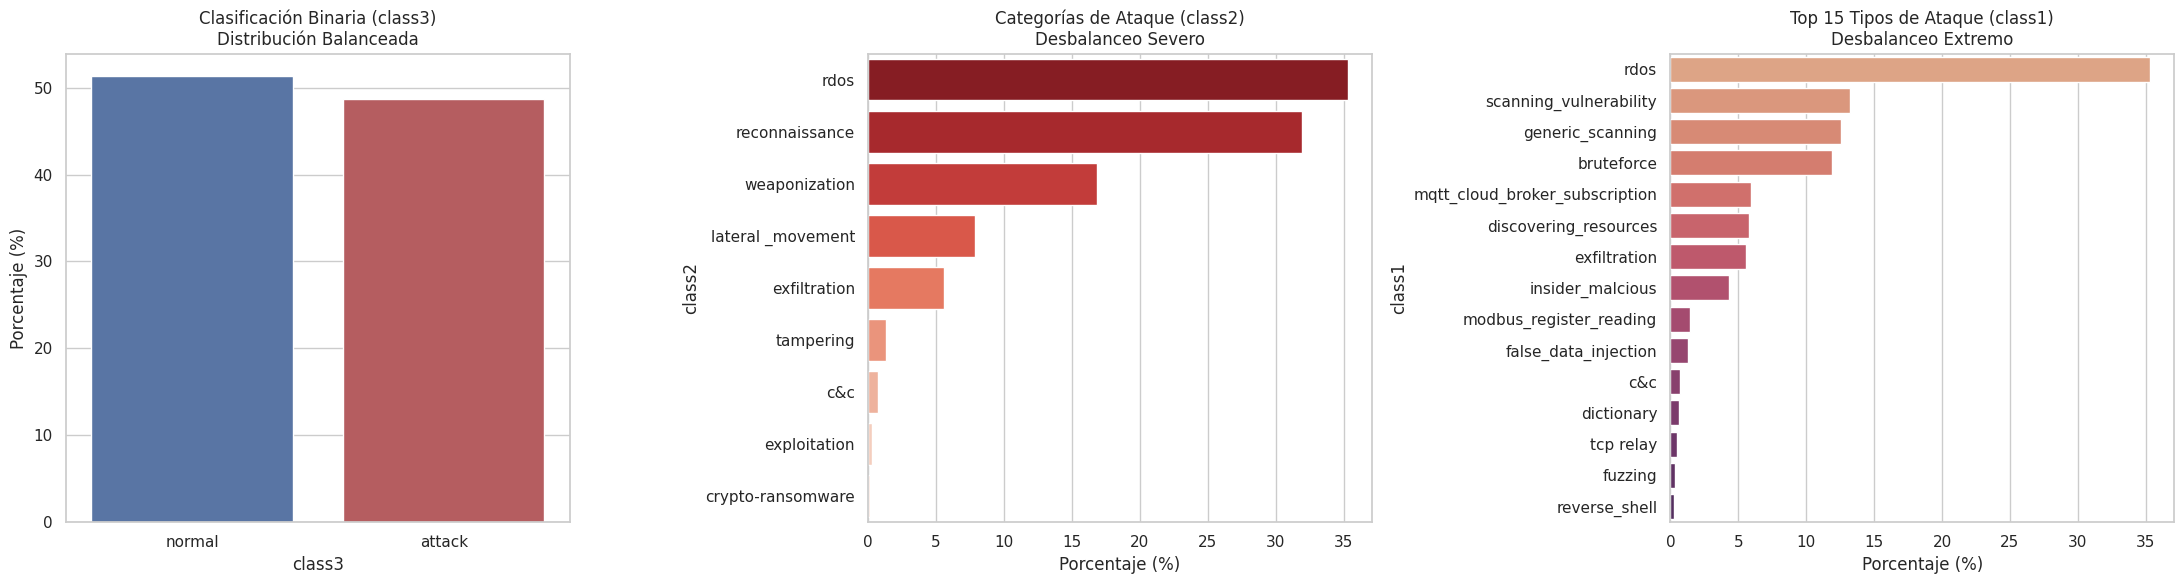

In [3]:
y = df[['class1', 'class2', 'class3']]
X = df.drop(columns=['class1', 'class2', 'class3'], errors='ignore')

# División 70% / 15% / 15% estratificada
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y['class3'])
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=(0.15/0.85), random_state=42, stratify=y_temp['class3'])

print("=== DISTRIBUCIÓN DE VARIABLES OBJETIVO ===")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Gráfica: Binaria (class3) - Demostramos el balanceo
conteo_c3 = y_train['class3'].value_counts(normalize=True) * 100
sns.barplot(x=conteo_c3.index, y=conteo_c3.values, palette=['#4C72B0', '#C44E52'], ax=axes[0])
axes[0].set_title('Clasificación Binaria (class3)\nDistribución Balanceada')
axes[0].set_ylabel('Porcentaje (%)')

# Filtramos los ataques para las gráficas multiclase
df_ataques = y_train[y_train['class3'] != 'normal']

# 2. Gráfica: Categorías de ataque (class2) - Demostramos desbalanceo
conteo_c2 = df_ataques['class2'].value_counts(normalize=True) * 100
sns.barplot(y=conteo_c2.index, x=conteo_c2.values, palette='Reds_r', ax=axes[1])
axes[1].set_title('Categorías de Ataque (class2)\nDesbalanceo Severo')
axes[1].set_xlabel('Porcentaje (%)')

# 3. Gráfica: Tipos de ataque (class1) - Demostramos desbalanceo
conteo_c1 = df_ataques['class1'].value_counts(normalize=True).head(15) * 100
sns.barplot(y=conteo_c1.index, x=conteo_c1.values, palette='flare', ax=axes[2])
axes[2].set_title('Top 15 Tipos de Ataque (class1)\nDesbalanceo Extremo')
axes[2].set_xlabel('Porcentaje (%)')

plt.tight_layout()
plt.show()

### 3. Análisis Exploratorio y Filtrado de Variables Predictoras
Uno de los objetivos principales de este proyecto es diseñar un modelo robusto que sea **agnóstico al dispositivo y a la topología de la red**. Si se incluyeran identificadores como direcciones IP o puertos, el modelo memorizaría la red de pruebas en lugar de aprender patrones de ataque. Por ello, se descartan proactivamente 16 características de enrutamiento y marcas temporales.

Posteriormente, se aplican tres filtros estadísticos rigurosos:
1. **Filtro de Varianza:** Se eliminan variables constantes o cuasi-constantes (varianza nula).
2. **Relevancia Lineal:** Se eliminan variables cuya correlación con el objetivo (`class3`) es inferior a 0.025.
3. **Filtro de Redundancia:** Se detectan características fuertemente correlacionadas entre sí (> 0.97) mediante clustering jerárquico para mitigar la multicolinealidad.

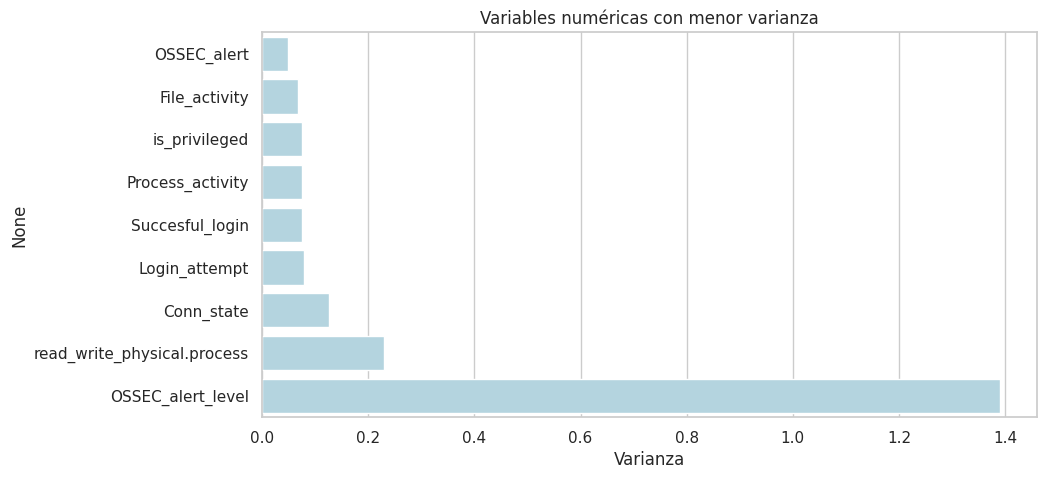

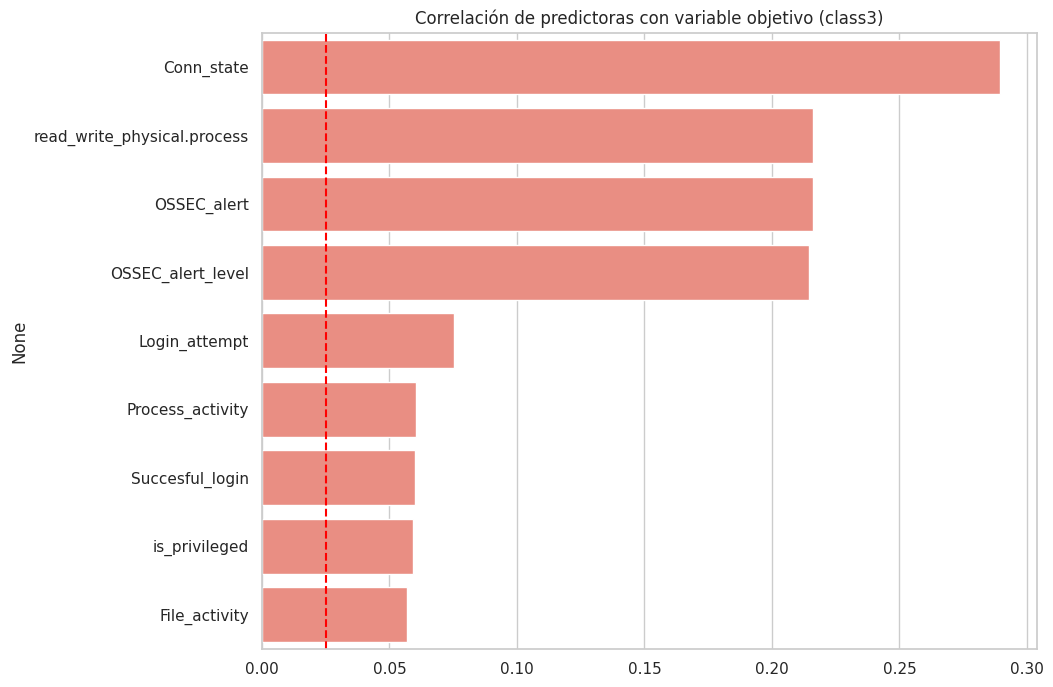

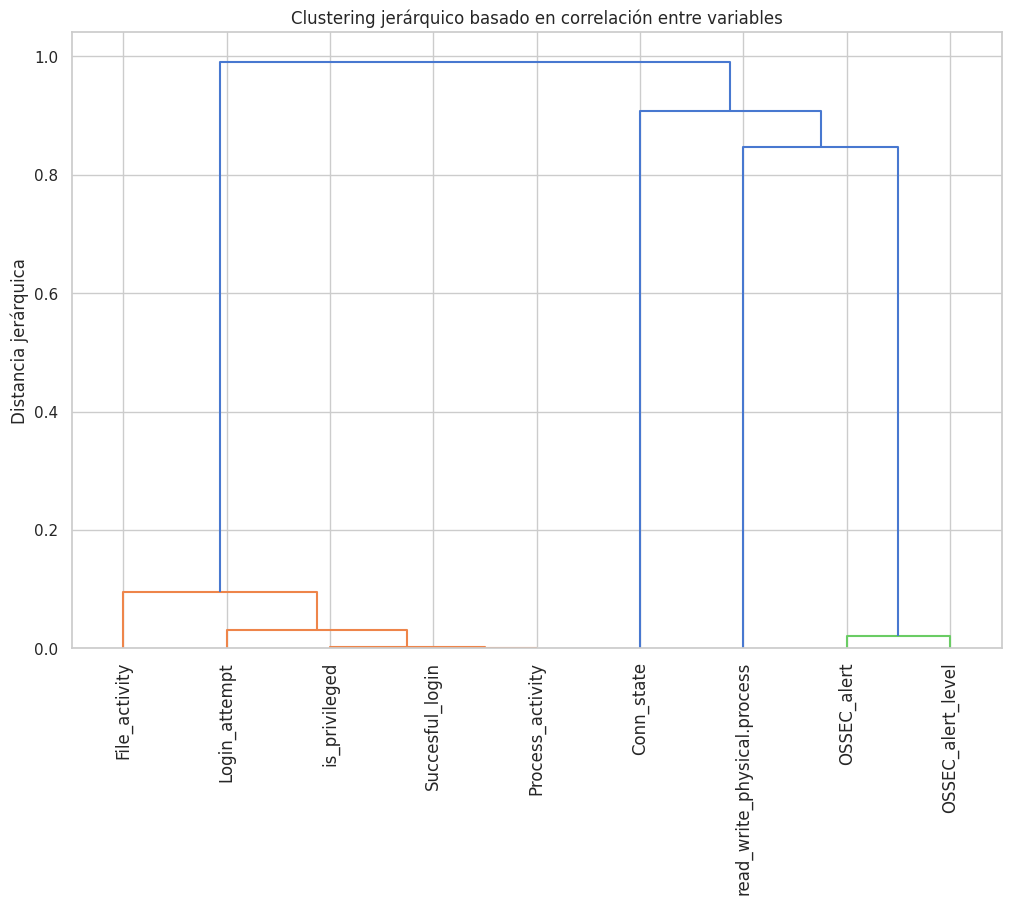

Características tras filtros (Varianza, Target, Redundancia): 45


In [4]:
# Eliminación de variables agnósticas (IPs, puertos, timestamps)
columnas_agnosticas = [
    'scr_ip', 'scr_port', 'des_ip', 'des_port', 'scr_bytes', 'des_bytes',
    'scr_pkts', 'des_pkts', 'scr_packts_ratio', 'des_pkts_ratio',
    'scr_bytes_ratio', 'des_bytes_ratio', 'scr_ip_bytes', 'des_ip_bytes',
    'timestamp', 'date'
]
columnas_a_borrar = [col for col in X_train.columns if col.lower() in columnas_agnosticas]
X_train = X_train.drop(columns=columnas_a_borrar)

numeric_train = X_train.select_dtypes(include=[np.number])

# --- 1. Filtro de Varianza ---
varianzas = numeric_train.var().sort_values()
plt.figure(figsize=(10, 5))
sns.barplot(x=varianzas.head(15).values, y=varianzas.head(15).index, color='lightblue')
plt.title('Variables numéricas con menor varianza')
plt.xlabel('Varianza')
plt.show()

# Eliminar varianza = 0
cols_var_0 = varianzas[varianzas == 0].index.tolist()
X_train = X_train.drop(columns=cols_var_0, errors='ignore')
numeric_train = numeric_train.drop(columns=cols_var_0, errors='ignore')

# --- 2. Correlación con el Target ---
y_train_bin = y_train['class3'].apply(lambda x: 0 if x == 'normal' else 1)
corr_with_target = numeric_train.apply(lambda col: col.corr(y_train_bin)).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index, color='salmon')
plt.title('Correlación de predictoras con variable objetivo (class3)')
plt.axvline(x=0.025, color='red', linestyle='--')
plt.show()

# Eliminar correlación < 0.025
cols_baja_corr = corr_with_target[corr_with_target < 0.025].index.tolist()
X_train = X_train.drop(columns=cols_baja_corr, errors='ignore')
numeric_train = numeric_train.drop(columns=cols_baja_corr, errors='ignore')

# --- 3. Clustering jerárquico (Redundancia) ---
corr_matrix = numeric_train.corr().abs()
dist_matrix = 1 - corr_matrix
linkage_matrix = hierarchy.linkage(squareform(dist_matrix), method='complete')

plt.figure(figsize=(12, 8))
hierarchy.dendrogram(linkage_matrix, labels=numeric_train.columns, leaf_rotation=90)
plt.title('Clustering jerárquico basado en correlación entre variables')
plt.ylabel('Distancia jerárquica')
plt.show()

# Eliminar redundantes > 0.97
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
cols_redundantes = [column for column in upper.columns if any(upper[column] > 0.97)]
X_train = X_train.drop(columns=cols_redundantes, errors='ignore')

print(f"Características tras filtros (Varianza, Target, Redundancia): {X_train.shape[1]}")

### 4. Evaluación de Importancia no lineal (Random Forest)
Además de los filtros lineales previos, se evalúa la importancia de las variables utilizando un ensamble de árboles de decisión (Random Forest). Este paso es crucial porque existen características que, a pesar de mostrar baja correlación lineal, resultan fundamentales para los algoritmos no lineales a la hora de trazar fronteras de decisión complejas.

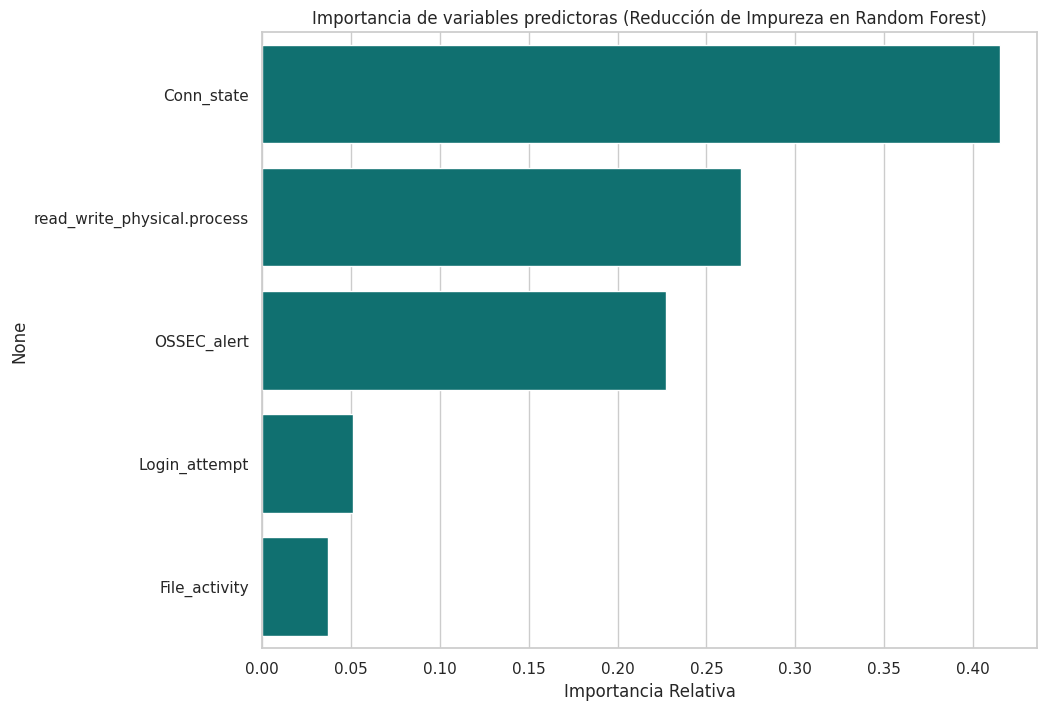

In [5]:
numeric_rf = X_train.select_dtypes(include=[np.number])

# Entrenamos con un subconjunto para agilizar el proceso de EDA
X_sample, _, y_sample, _ = train_test_split(numeric_rf, y_train_bin, train_size=25000, random_state=42, stratify=y_train_bin)

rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

importancias = pd.Series(rf.feature_importances_, index=numeric_rf.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importancias.head(20).values, y=importancias.head(20).index, color='teal')
plt.title('Importancia de variables predictoras (Reducción de Impureza en Random Forest)')
plt.xlabel('Importancia Relativa')
plt.show()

### 5. Pipeline Final de Preprocesamiento y PCAFSS
Una vez depurado el espacio de características, se establece el pipeline de transformación final que se aplicará a los conjuntos de entrenamiento, validación y prueba:

1. **Imputación:** Se utiliza la media para rellenar los valores nulos numéricos (así como los booleanos, asumiéndolos como probabilidades en el rango 0-1). Las variables categóricas se unifican bajo la etiqueta `missing`.
2. **Escalado Robusto:** Se aplica `RobustScaler` debido a nuestra decisión estratégica de conservar los valores atípicos.
3. **Codificación Categórica:** Se utiliza `One-Hot Encoding` para evitar que los algoritmos asuman un orden numérico irreal en variables como el protocolo o el servicio.
4. **Selección por PCA (PCAFSS):** Finalmente, se extraen las variables originales más representativas basándose en los componentes principales que explican el 95% de la varianza. Se opta por retener las variables físicas originales (en lugar de las transformaciones matemáticas de PCA) para mantener la explicabilidad del modelo en el entorno industrial.

In [7]:
import gc

X_val = X_val[X_train.columns]
X_test = X_test[X_train.columns]

if len(X_train) > 10000:
    X_train = X_train.sample(n=10000, random_state=42)
    y_train = y_train.loc[X_train.index]

cols_cat = X_train.select_dtypes(include=['object']).columns.tolist()
cols_num_bool = X_train.select_dtypes(exclude=['object']).columns.tolist()

X_train[cols_num_bool] = X_train[cols_num_bool].astype(np.float32)

if cols_num_bool:
    imputer_num = SimpleImputer(strategy='mean')
    X_train[cols_num_bool] = imputer_num.fit_transform(X_train[cols_num_bool])
    X_val[cols_num_bool] = imputer_num.transform(X_val[cols_num_bool].astype(np.float32))
    X_test[cols_num_bool] = imputer_num.transform(X_test[cols_num_bool].astype(np.float32))

if cols_cat:
    for col in cols_cat:
        X_train[col] = X_train[col].fillna('missing')
        X_val[col] = X_val[col].fillna('missing')
        X_test[col] = X_test[col].fillna('missing')

if cols_num_bool:
    scaler = RobustScaler()
    X_train[cols_num_bool] = scaler.fit_transform(X_train[cols_num_bool]).astype(np.float32)
    X_val[cols_num_bool] = scaler.transform(X_val[cols_num_bool]).astype(np.float32)
    X_test[cols_num_bool] = scaler.transform(X_test[cols_num_bool]).astype(np.float32)

if cols_cat:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32)

    encoded_train = encoder.fit_transform(X_train[cols_cat])
    X_train.drop(columns=cols_cat, inplace=True)
    X_train = pd.concat([X_train, pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(cols_cat), index=X_train.index)], axis=1)
    del encoded_train

    encoded_val = encoder.transform(X_val[cols_cat])
    X_val.drop(columns=cols_cat, inplace=True)
    X_val = pd.concat([X_val, pd.DataFrame(encoded_val, columns=encoder.get_feature_names_out(cols_cat), index=X_val.index)], axis=1)
    del encoded_val

    encoded_test = encoder.transform(X_test[cols_cat])
    X_test.drop(columns=cols_cat, inplace=True)
    X_test = pd.concat([X_test, pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(cols_cat), index=X_test.index)], axis=1)
    del encoded_test
    gc.collect()

pca = PCA(n_components=0.95, random_state=42)
pca.fit(X_train)

importancia_pca = np.sum(np.abs(pca.components_), axis=0)
indices_top_pca = np.argsort(importancia_pca)[::-1][:30]
cols_pcafss = X_train.columns[indices_top_pca]

X_train_final = X_train[cols_pcafss].copy()
X_val_final = X_val[cols_pcafss].copy()
X_test_final = X_test[cols_pcafss].copy()

n_comp = pca.n_components_
del X_train, X_val, X_test, pca
gc.collect()

print(f"Preprocesamiento finalizado.")
print(f"Componentes PCA (95% var): {n_comp}")
print(f"Dimensiones finales: {X_train_final.shape}")

Preprocesamiento finalizado.
Componentes PCA (95% var): 4
Dimensiones finales: (10000, 12)


### 6. Conclusiones del Análisis y Preparación para el Modelado <a name="6"></a>

Tras aplicar exhaustivamente el flujo de exploración y procesamiento de datos sobre el conjunto **X-IIoTID**, extraemos las siguientes conclusiones técnicas que definirán la arquitectura del próximo hito:

1. **Diseño Agnóstico y Eficiencia Dimensional:** La decisión estratégica de eliminar las variables dependientes de la red física (IPs, puertos, timestamps), combinada con el triple filtro estadístico (Varianza, Relevancia y Redundancia), garantiza que el futuro modelo aprenderá patrones de comportamiento generalizables y no memorizará simplemente la topología de la red de pruebas.
2. **Tratamiento del Desbalanceo:** Aunque a nivel binario el conjunto de datos es estable, el análisis de las variables objetivo ha revelado un desbalanceo extremo en las subcategorías específicas de los ciberataques. Esta evidencia exigirá que las futuras arquitecturas multiclase integren técnicas de compensación algorítmica, como la ponderación de pesos (class weights), durante la fase de entrenamiento.
3. **Fronteras de Decisión Complejas:** La retención deliberada de los valores atípicos (outliers) y la evaluación de importancia mediante Random Forest demuestran que el tráfico malicioso avanzado emula fielmente las métricas del tráfico legítimo. Al no existir una separabilidad lineal clara, se justifica rigurosamente la necesidad de emplear algoritmos complejos y no lineales (como ensambles de árboles o redes neuronales profundas) para la fase de detección.

En definitiva, el pipeline de preprocesamiento diseñado ha generado un espacio de datos robusto, dimensionalmente eficiente y libre de sesgos topológicos. El entorno se encuentra preparado de forma óptima para iniciar la fase de modelado y experimentación algorítmica.